# Detecção de Intenção em Chatbots Bancários

### Motivação: 

atualmente estou em um IC onde estou resposável por uma ia generativa para um chabot dentro do contexto de desastres naturais e como o uso é destinado a pessoas com menos escolaridade e trata de diversos topicos é preciso tratar bem o escopo e reconhecer a verdadeira inteção da mensagem. E através desse cenário posso ter uma base para trabalhar melhor em outros contextos.

considerei traduzir os dados para portugues mas na minha máquina foi mais de 50 minutos rodando e ainda não tinha terminado então optei seguir com eles em inglês, mas é algo que mas que faça uma versão paralela é algo que quero tentar pois se encaixa ainda mais dentro do problema que trabalho na IC.
### Objetivo:

Reduzir custos com atendimento humano usando um chatbot que entenda a intenção do cliente. \

então nosso foco é em automatizar o atendimento ao cliente classificando perguntas em intenções como:

"bloquear_cartao"

"consultar_saldo"

"transferencia"

"reclamacao"

## Sobre o dataset
O conjunto de dados BANKING77 fornece dados focados em de intenções em um domínio bancário.
Ele compreende 40.000 consultas de atendimento ao cliente rotuladas com 77 intenções.
Ele se concentra na detecção refinada de intenções de domínio único.


Exemplo de dados:

`{"text": "How do I block my card?", "category": "block_card}"`


*o dataset já veio separado entre treino e teste, seguindo a proporção 70/30*

[Treino](https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv) e
[Teste](https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv) \
Repositorio do BANKING77 [aqui](https://huggingface.co/datasets/PolyAI/banking77/blob/main/banking77.py)

### Carregamento dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [45]:
train_df = pd.read_csv('data/train.csv')  
test_df = pd.read_csv('data/test.csv')  

forma do nosso dataset

In [46]:
print("Treino:", train_df.shape)
print("Teste:", test_df.shape)

Treino: (10003, 2)
Teste: (3080, 2)


verificando presença de valores nulo

In [50]:
print("Dados de treino - Valores nulos:\n", train_df.isnull().sum())

Dados de treino - Valores nulos:
 text        0
category    0
dtype: int64


no geral esse dataset veio praticamente "limpo" então não fiz muita coisa na fase de limpeeza dos dados.

### Estatísticas Básicas
Número de Intenções Únicas

In [51]:
num_intents = train_df['category'].nunique()
print(f"Número de intenções únicas: {num_intents}")

intent_counts = train_df['category'].value_counts()
print("\nTop 5 intenções mais frequentes:")
print(intent_counts.head())

Número de intenções únicas: 77

Top 5 intenções mais frequentes:
category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
Name: count, dtype: int64


Distribuição das Classes

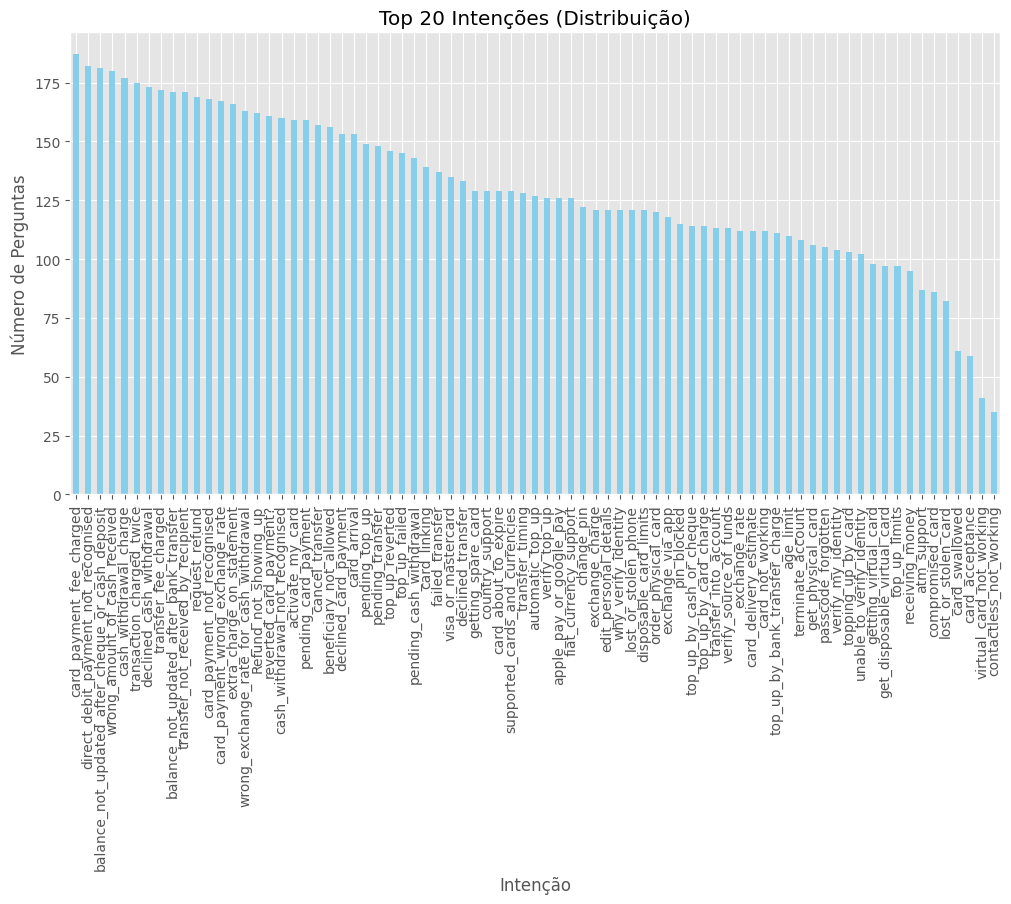

In [52]:
plt.figure(figsize=(12, 6))
intent_counts.plot(kind='bar', color='skyblue')
plt.title("Top 20 Intenções (Distribuição)")
plt.xlabel("Intenção")
plt.ylabel("Número de Perguntas")
plt.show()

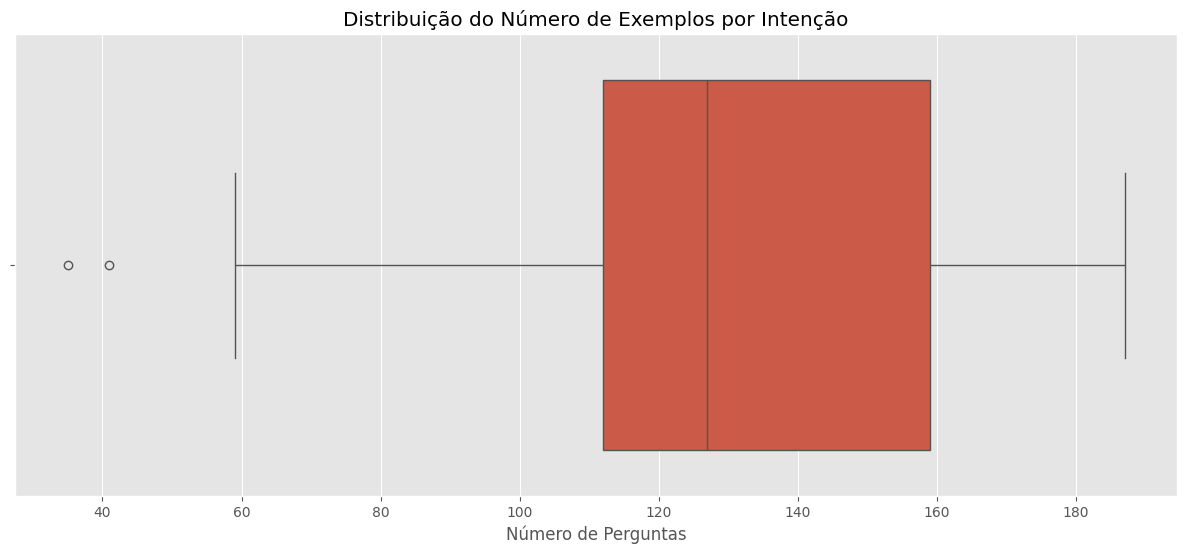

In [53]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=train_df['category'].value_counts().values)
plt.title("Distribuição do Número de Exemplos por Intenção")
plt.xlabel("Número de Perguntas")
plt.show()

Analisando os tamanhos das perguntas

Média de palavras por pergunta: 11.9
Máximo de palavras: 79
Mínimo de palavras: 2


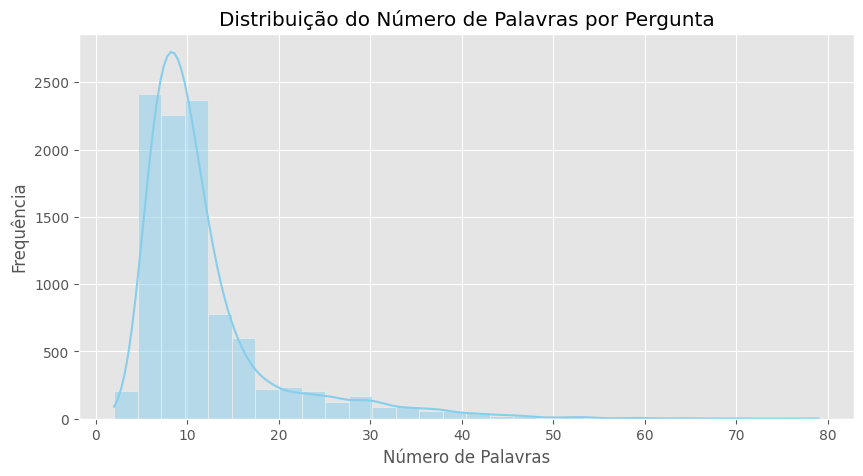

In [54]:
# Calcular tamanho das perguntas
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

# Estatísticas
print(f"Média de palavras por pergunta: {train_df['word_count'].mean():.1f}")
print(f"Máximo de palavras: {train_df['word_count'].max()}")
print(f"Mínimo de palavras: {train_df['word_count'].min()}")

# Histograma
plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=30, kde=True, color='skyblue')
plt.title("Distribuição do Número de Palavras por Pergunta")
plt.xlabel("Número de Palavras")
plt.ylabel("Frequência")
plt.show()

analisando as palavras sem stopwords mais frequentes

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dinorah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_11611/3854249942.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')


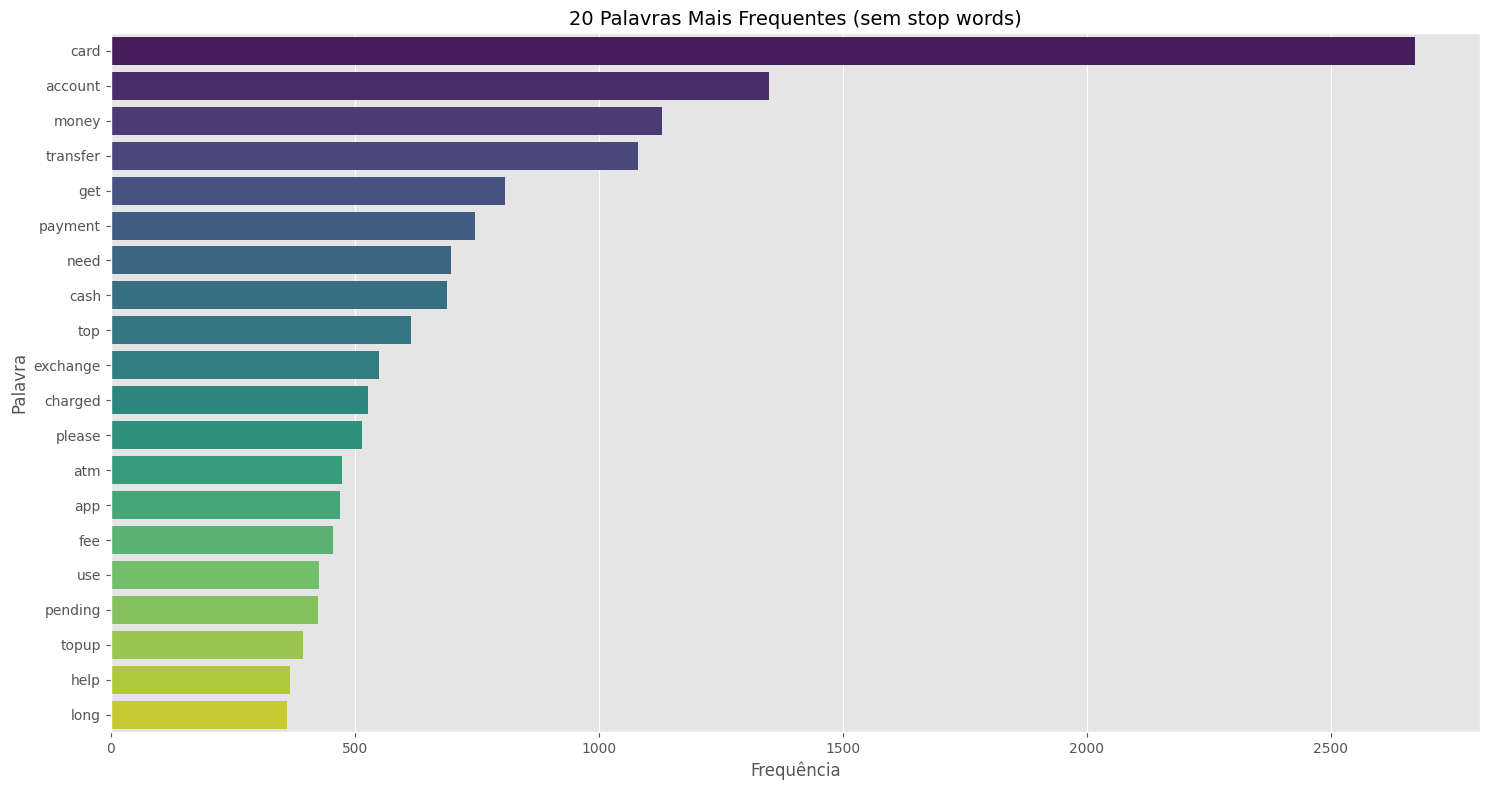

In [65]:
from collections import Counter  
from nltk.corpus import stopwords
import re
import nltk

nltk.download('stopwords')

def preprocess(text):
    
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  
    
    # remover stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    
    return words

all_words_clean = []
for text in train_df['text']:
    all_words_clean.extend(preprocess(text))


word_freq = Counter(all_words_clean)
top_words = word_freq.most_common(20)  

top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(15, 8))
sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')
plt.title('20 Palavras Mais Frequentes (sem stop words)', fontsize=14)
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Palavra', fontsize=12)
plt.tight_layout()
plt.show()

### insights

* O dataset tem 77 intenções, sendo as 3 mais frequentes card_payment_fee_charged, direct_debit_payment_not_recognised e balance_not_updated_after_cheque_or_cash_deposit 
* Temos clases moderadamente desbalanceadas. iremos dar pesos as clases na hora do treinamento como forma de tentar minimizar um possivel enviesamento
* Média de palavras por pergunta: 11.9 indica interações curtas-médias
* as palavras mais usadas estão dentro do esperado para o contexto

explorando ainda algumas visualizacoes geramos uma wordcloud de algumas clases para ver se aparece algo incomum

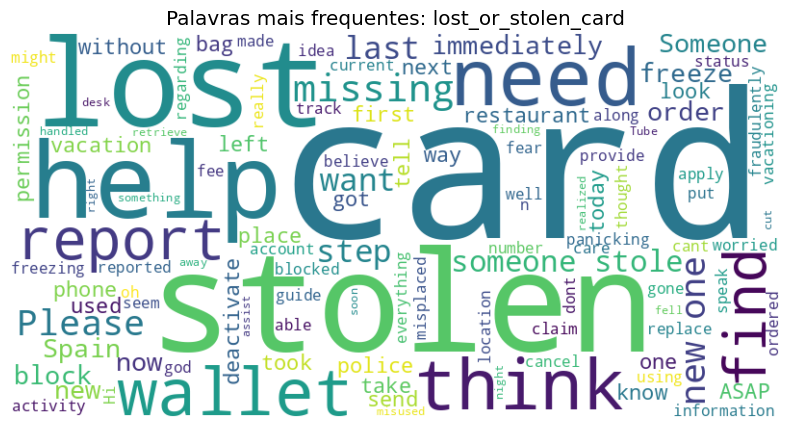

In [55]:
# Função para gerar wordcloud
def generate_wordcloud(intent):
    text = " ".join(train_df[train_df['category'] == intent]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Palavras mais frequentes: {intent}")
    plt.show()

generate_wordcloud('lost_or_stolen_card')

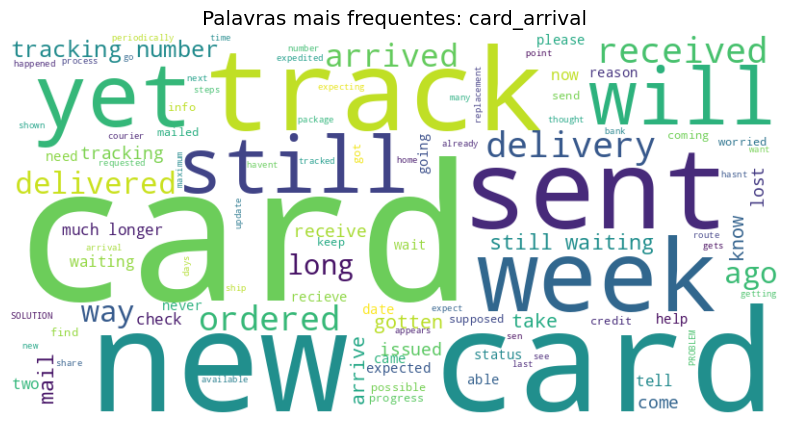

In [69]:
generate_wordcloud('card_arrival')

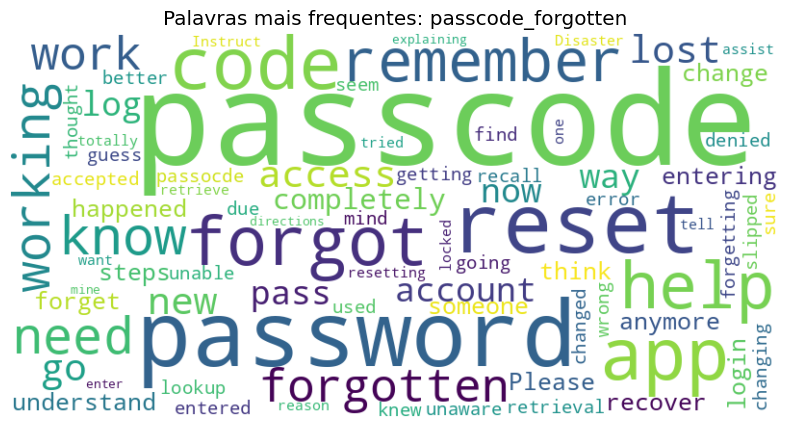

In [70]:
generate_wordcloud('passcode_forgotten')

## Pré Processamento

In [56]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /home/dinorah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dinorah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dinorah/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/dinorah/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [57]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        10003 non-null  object
 1   category    10003 non-null  object
 2   word_count  10003 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.6+ KB


In [ ]:
import string
import pandas as pd
from nltk.tokenize import TreebankWordTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

tokenizer = TreebankWordTokenizer()
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ''.join([char for char in text if not char.isdigit()])
    tokens = tokenizer.tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalpha() and t not in stop_words]
    return " ".join(tokens)

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

train_df['text_processed'] = train_df['text'].apply(preprocess_text)
test_df['text_processed'] = test_df['text'].apply(preprocess_text)

In [59]:
print("Original:", train_df['text'].iloc[0])
print("Processado:", train_df['text_processed'].iloc[0])

Original: I am still waiting on my card?
Processado: still waiting card


Em um contexto bancário, números como valores de transações, números de cartão, contas, senha podem ser considerados dados sensiveis, então nesse caso optei por retirar os caracteres numericos

### Extração de features

In [60]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Carregar um modelo leve e rápido
model = SentenceTransformer('all-MiniLM-L6-v2')

# Gerar embeddings para os dados processados
X_train = model.encode(train_df['text_processed'].tolist(), show_progress_bar=True)
X_test = model.encode(test_df['text_processed'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 97/97 [00:00<00:00, 139.72it/s]


### Matriz de Similaridade

analisando a matriz de similaridade analisei as 5 primeiras entradas, considerando são da mesma categoria temos que 
* Alto grau de similaridade entre as 3 primeiras perguntas, corroborando com os dados
* Queda na similaridade a partir da 4ª pergunta, podendo haver uma mudança sutil de tema, ou a linguagem usada seja menos padronizada
* A média (0.6704) reforça a proximidade geral

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calcular a similaridade entre dois exemplos
similarity_example = cosine_similarity([X_train[0]], [X_train[1]])  # Exemplo entre duas primeiras perguntas
print(f"Similaridade entre as primeiras perguntas: {similarity_example[0][0]:.4f}")

# Calcular a similaridade entre todos os pares de embeddings (matriz de similaridade)
similarity_matrix = cosine_similarity(X_train)
print("Matriz de Similaridade (primeiras 5 perguntas):")
print(similarity_matrix[:152, :152])  


Similaridade entre as primeiras perguntas: 0.6704
Matriz de Similaridade (primeiras 5 perguntas):
[[1.         0.6704168  0.73237896 ... 0.38266215 0.5558119  0.7172401 ]
 [0.6704168  0.99999994 0.8141346  ... 0.377829   0.6467639  0.8458122 ]
 [0.73237896 0.8141346  1.0000002  ... 0.27430826 0.49459442 0.630306  ]
 ...
 [0.38266215 0.377829   0.27430826 ... 1.         0.5139089  0.4734134 ]
 [0.5558119  0.6467639  0.49459442 ... 0.5139089  1.0000002  0.67442155]
 [0.7172401  0.8458122  0.630306   ... 0.4734134  0.67442155 1.0000002 ]]


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calcular matriz de similaridade entre as 40 primeiras perguntas
similarity = cosine_similarity(X_train[:152])

# Criar uma máscara para excluir a diagonal principal
mask = ~np.eye(similarity.shape[0], dtype=bool)

# Calcular a média excluindo os valores da diagonal (auto-similaridade = 1)
mean_similarity_40 = similarity[mask].mean()

print("Matriz de Similaridade (40x40):")
print(similarity)

print(f"\nMédia de similaridade entre as 152 primeiras perguntas: {mean_similarity_40:.4f}")


Matriz de Similaridade (40x40):
[[1.         0.6704168  0.73237896 ... 0.7463325  0.6843492  0.60909873]
 [0.6704168  0.99999994 0.8141346  ... 0.8639711  0.9581059  0.8182733 ]
 [0.73237896 0.8141346  1.0000002  ... 0.6693922  0.7671617  0.5844769 ]
 ...
 [0.7463325  0.8639711  0.6693922  ... 0.99999994 0.8676838  0.84694135]
 [0.6843492  0.9581059  0.7671617  ... 0.8676838  1.         0.82368505]
 [0.60909873 0.8182733  0.5844769  ... 0.84694135 0.82368505 0.9999998 ]]

Média de similaridade entre as 40 primeiras perguntas: 0.5456


                                                    text         category  \
90     Is there a way to track the new card you sent me?     card_arrival   
91                        I'm still waiting for my card.     card_arrival   
92     What do I need to do to get my new card which ...     card_arrival   
93                  WHAT IS THE SOLUTION OF THIS PROBLEM     card_arrival   
94                     Could I get tracking on the card?     card_arrival   
...                                                  ...              ...   
9998              You provide support in what countries?  country_support   
9999                  What countries are you supporting?  country_support   
10000                What countries are getting support?  country_support   
10001                     Are cards available in the EU?  country_support   
10002                   Which countries are represented?  country_support   

                             text_processed  
90                  way track

In [73]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calcular matriz de similaridade entre as 40 primeiras perguntas
similarity_40 = cosine_similarity(X_train[42:82])

# Criar uma máscara para excluir a diagonal principal
mask = ~np.eye(similarity_40.shape[0], dtype=bool)

# Calcular a média excluindo os valores da diagonal (auto-similaridade = 1)
mean_similarity_40 = similarity_40[mask].mean()

print("Matriz de Similaridade (40x40):")
print(similarity_40)

print(f"\nMédia de similaridade entre as 40 primeiras perguntas: {mean_similarity_40:.4f}")


Matriz de Similaridade (40x40):
[[0.9999999  0.48389935 0.71757483 ... 0.24923961 0.75788414 0.7008741 ]
 [0.48389935 1.0000002  0.5039896  ... 0.22523794 0.3897664  0.4097896 ]
 [0.71757483 0.5039896  0.99999994 ... 0.22396556 0.7991051  0.59467083]
 ...
 [0.24923961 0.22523794 0.22396556 ... 1.0000001  0.25144342 0.22274664]
 [0.75788414 0.3897664  0.7991051  ... 0.25144342 0.9999998  0.6306516 ]
 [0.7008741  0.4097896  0.59467083 ... 0.22274664 0.6306516  1.0000002 ]]

Média de similaridade entre as 40 primeiras perguntas: 0.5375


### Visualização dos embeddings usando t-SNE

Exception ignored on calling ctypes callback function <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f6ce283fe20>:
Traceback (most recent call last):
  File "/home/dinorah/ufrn/NLP/intentRecognizion/npl/lib64/python3.13/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/dinorah/ufrn/NLP/intentRecognizion/npl/lib64/python3.13/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/home/dinorah/ufrn/NLP/intentRecognizion/npl/lib64/python3.13/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib64/python3.13/ctypes/__init__.py", line 390, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: dlopen() error


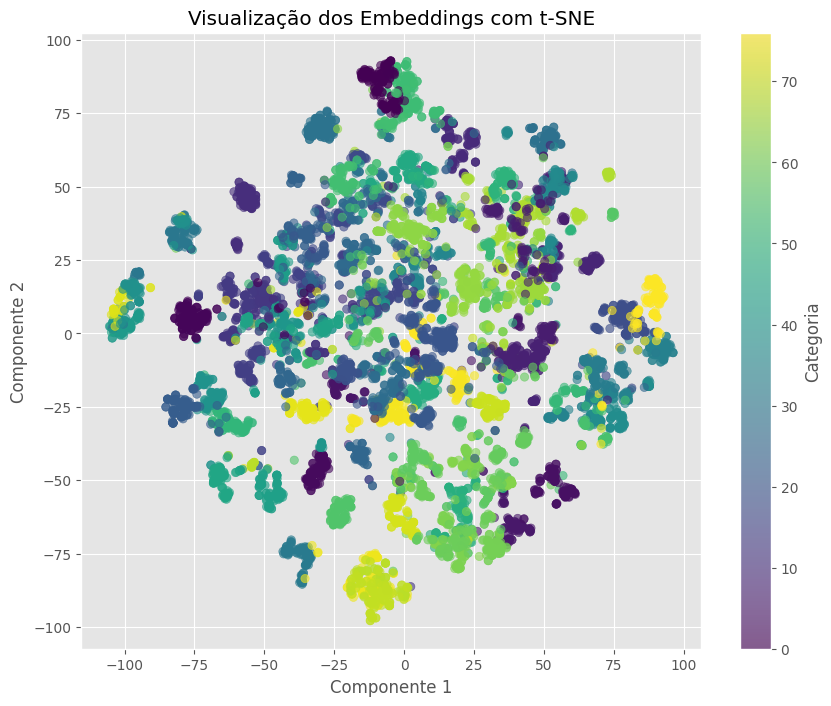

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduzir a dimensionalidade com t-SNESX_tsne = tsne.fit_transform(X_train)

# Plotar os resultados
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=train_df['category'].astype('category').cat.codes, cmap='viridis', alpha=0.6)
plt.colorbar(label='Categoria')
plt.title("Visualização dos Embeddings com t-SNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()


desse gráfico podemos inferir que:
* clusters visiveis indicando um agrupamento por similaridade
* uma certa separação entre diferente categorias indicando ainda mais os clusters\
* mas ainda sim temos uma sobreposição, oque significa que algumas categorias diferentes podem ter certas similaridades\
* indica uma melhora nos embeddings acho que podemos melhorar ainda mais a qualidade dos embeddings\